### PRN: 260240128052                                                                           
### Name: Varad Milind Kulkarni
### PRN: 260240128054                                                                             
### Name: Vivek Rakesh Gotecha

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss,accuracy_score,f1_score,balanced_accuracy_score
import os
from xgboost import XGBClassifier
from sklearn.manifold import TSNE
os.chdir('/home/pgcp-ai/MachineLearning/Datasets/IrrigationNeed/')

/home/pgcp-ai/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
df = pd.read_csv('train.csv',index_col='id')
df

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Water_Sou

In [4]:
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore').set_output(transform='pandas')
ss = StandardScaler().set_output(transform='pandas')

In [5]:
transformer = ColumnTransformer(transformers = [('OHE',ohe,make_column_selector(dtype_include=object))],
                               remainder='passthrough',
                               verbose_feature_names_out=False,
                               ).set_output(transform = 'pandas')

In [6]:
X,y = df.drop('Irrigation_Need',axis=1), df['Irrigation_Need']

In [7]:
le = LabelEncoder()

In [8]:
y = le.fit_transform(y)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [10]:
X_train_ohe = transformer.fit_transform(X_train)
X_test_ohe = transformer.transform(X_test)

In [11]:
X_train_scaled = ss.fit_transform(X_train_ohe)
X_test_scaled = ss.transform(X_test_ohe)

In [ ]:
tsne = TSNE(random_state = 26, n_jobs= -1).set_output(transform = 'pandas')
X_tsne = tsne.fit_transform(X_train_scaled)


<Axes: xlabel='tsne0', ylabel='tsne1'>

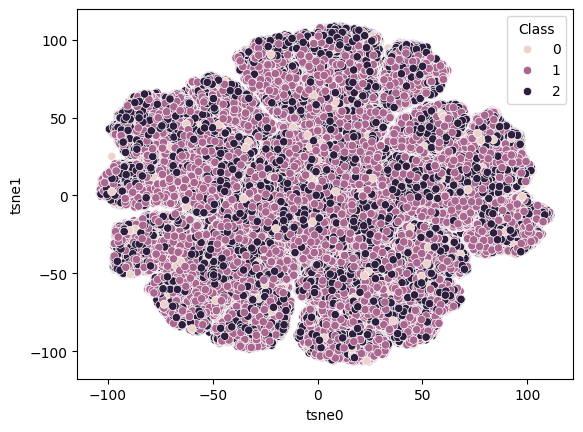

In [15]:
X_tsne['Class'] = y_train
sns.scatterplot(data = X_tsne, x = 'tsne0', y = 'tsne1', hue = 'Class')

In [ ]:
X_ohe = transformer.fit_transform(X)
X_ss = ss.fit_transform(X_ohe)


In [ ]:
tst = pd.read_csv("test.csv", index_col = 'id')

In [ ]:
tst_ohe = transformer.transform(tst)

In [ ]:
tst_ss = ss.transform(tst_ohe)

In [ ]:
tst['Irrigation_Need'] = le.inverse_transform(bm.predict(tst_ss))
tst

In [ ]:
submission = pd.read_csv("sample_submission.csv")
submission['Irrigation_Need'] = le.inverse_transform(bm.predict(tst_ss))
submission

In [ ]:
submission.to_csv("Kaggle_submission.csv", index = False)

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train_scaled,y_train)

In [ ]:
y_pred = xgb.predict(X_test_scaled)
y_pred_prob = xgb.predict_proba(X_test_scaled)

accuracy_score(y_test,y_pred)

In [ ]:
log_loss(y_test,y_pred_prob)

In [ ]:
balanced_accuracy_score(y_test,y_pred)

In [ ]:
lgbm = LGBMClassifier(random_state=26,verbose=-1)
lgbm.fit(X_train_scaled,y_train)
y_pred = lgbm.predict(X_test_scaled)
y_pred_prob = lgbm.predict_proba(X_test_scaled)
balanced_accuracy_score(y_test,y_pred),log_loss(y_test,y_pred_prob)

In [ ]:
list(X.select_dtypes(include=object).columns)

In [ ]:
cat = CatBoostClassifier(random_state=26,verbose=0)
cat.fit(X_train_scaled,y_train)
y_pred = cat.predict(X_test_scaled)
y_pred_prob = cat.predict_proba(X_test_scaled)
balanced_accuracy_score(y_test,y_pred),log_loss(y_test,y_pred_prob)

In [ ]:
rf = RandomForestClassifier(random_state=26)

In [ ]:
cat = CatBoostClassifier(random_state=26,verbose=0)


In [ ]:
voting = VotingClassifier(estimators = [('RF',rf),('XGB',xgb),('CAT',cat)],weights=[0.5,0.6,0.7],voting='soft')

In [ ]:
voting.fit(X_train_scaled,y_train)
y_pred_voting = voting.predict(X_test_scaled)
y_pred_prob_voting = voting.predict_proba(X_test_scaled)
balanced_accuracy_score(y_test,y_pred_voting),log_loss(y_test,y_pred_prob_voting)